In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier


In [ ]:
tree=pd.read_csv("/content/drive/MyDrive/Copy of Tree_Sterility_Dataset.csv")

In [ ]:
tree

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2778,7165,17,B,Prunus serotina,0.111,Med,2017,Populus grandidentata,891,Non-Sterile,...,40.89,NaN,0.83,9.15,11.88,16,56.0,1.0,NaN,NaN
2779,7217,17,D,Quercus alba,0.118,Med,2017,Acer rubrum,1468,Non-Sterile,...,15.47,32.82,4.88,19.01,23.50,16,56.0,1.0,NaN,NaN
2780,7306,17,D,Quercus alba,0.118,Med,2017,Quercus rubra,1454,Non-Sterile,...,11.96,37.67,5.51,21.13,19.10,16,56.0,1.0,NaN,NaN
2781,7771,18,D,Quercus alba,0.161,High,2017,Sterile,1297,Sterile,...,16.99,22.51,4.28,19.38,21.36,33,115.5,NaN,NaN,NaN


In [ ]:
tree.head(10)

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN
5,18,1,C,Prunus serotina,0.106,Med,2016,Acer rubrum,1332,Non-Sterile,...,35.29,NaN,0.30,10.80,13.79,7,24.5,1.0,NaN,NaN
6,25,1,A,Quercus alba,0.108,Med,2016,Populus grandidentata,891,Non-Sterile,...,24.00,20.00,5.11,18.82,22.51,7,24.5,0.0,X,NaN
7,40,1,A,Quercus rubra,0.108,Med,2017,Sterile,1595,Sterile,...,4.00,0.00,3.43,25.22,14.81,7,24.5,0.0,X,NaN
8,26,1,A,Quercus rubra,0.108,Med,2016,Acer saccharum,1323,Non-Sterile,...,28.74,36.18,3.83,26.65,14.65,33,115.5,0.0,NaN,X
9,41,1,A,Acer saccharum,0.108,Med,2016,Populus grandidentata,394,Non-Sterile,...,14.16,NaN,-0.05,13.30,12.16,7,24.5,1.0,NaN,NaN


In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(tree.shape,tree.shape[0],tree.shape[1]))

Shape of the dataset is (2783, 24). This dataset contains 2783 rows and 24 columns.


In [ ]:
tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDate    2783 non-null   object 
 14  AMF          2783 non-null   float64
 15  EMF          1283 non-null   float64
 16  Phenolics    2783 non-null   float64
 17  Lignin       2783 non-null   float64
 18  NSC          2783 non-null   float64
 19  Census

In [ ]:
tree['Sterile'].value_counts()


,count
Sterile,
Non-Sterile,2360
Sterile,423


In [ ]:
numerical_data = tree.select_dtypes(include='number')

numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 12 numerical features: 

['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']


In [ ]:
categorical_data=tree.select_dtypes(include= 'object')

categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 12 categorical features: 

['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'Harvest', 'Alive']


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
No,2783.0,3914.513834,2253.515063,3.000,1971.000,3932.000,5879.000,7772.000
Plot,2783.0,9.561624,5.203659,1.000,5.000,10.000,14.000,18.000
Light_ISF,2783.0,0.085707,0.025638,0.032,0.066,0.082,0.100,0.161
Core,2783.0,2016.648940,0.477387,2016.000,2016.000,2017.000,2017.000,2017.000
AMF,2783.0,20.553069,12.309587,0.000,13.400,18.000,24.445,100.000
EMF,1283.0,26.476750,16.636890,0.000,13.780,27.720,35.710,87.500
Phenolics,2783.0,1.933105,1.969842,-1.350,0.170,0.750,3.780,6.100
Lignin,2783.0,15.759792,6.779607,2.230,10.355,14.040,21.115,32.770
NSC,2783.0,14.219641,4.298271,4.300,11.605,12.660,17.275,29.450
Census,2783.0,15.282070,9.166555,4.000,7.000,13.000,18.000,33.000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Subplot,2783,5,A,701
Species,2783,4,Acer saccharum,751
Light_Cat,2783,3,Med,1474
Soil,2783,7,Sterile,423
Adult,2783,36,I,90
Sterile,2783,2,Non-Sterile,2360
Conspecific,2783,3,Heterospecific,1974
Myco,2783,2,AMF,1500
SoilMyco,2783,3,AMF,1186
PlantDate,2783,19,6/7/18,340


In [ ]:
numerical_data.var()

,0
No,5.078330e+06
Plot,2.707807e+01
Light_ISF,6.572914e-04
Core,2.278988e-01
AMF,1.515259e+02
EMF,2.767861e+02
Phenolics,3.880277e+00
Lignin,4.596307e+01
NSC,1.847513e+01
Census,8.402573e+01


In [ ]:
numerical_data.skew()

,0
No,-0.013436
Plot,-0.012063
Light_ISF,0.658495
Core,-0.624428
AMF,1.530073
EMF,0.504768
Phenolics,0.325592
Lignin,0.141701
NSC,0.569887
Census,1.033268


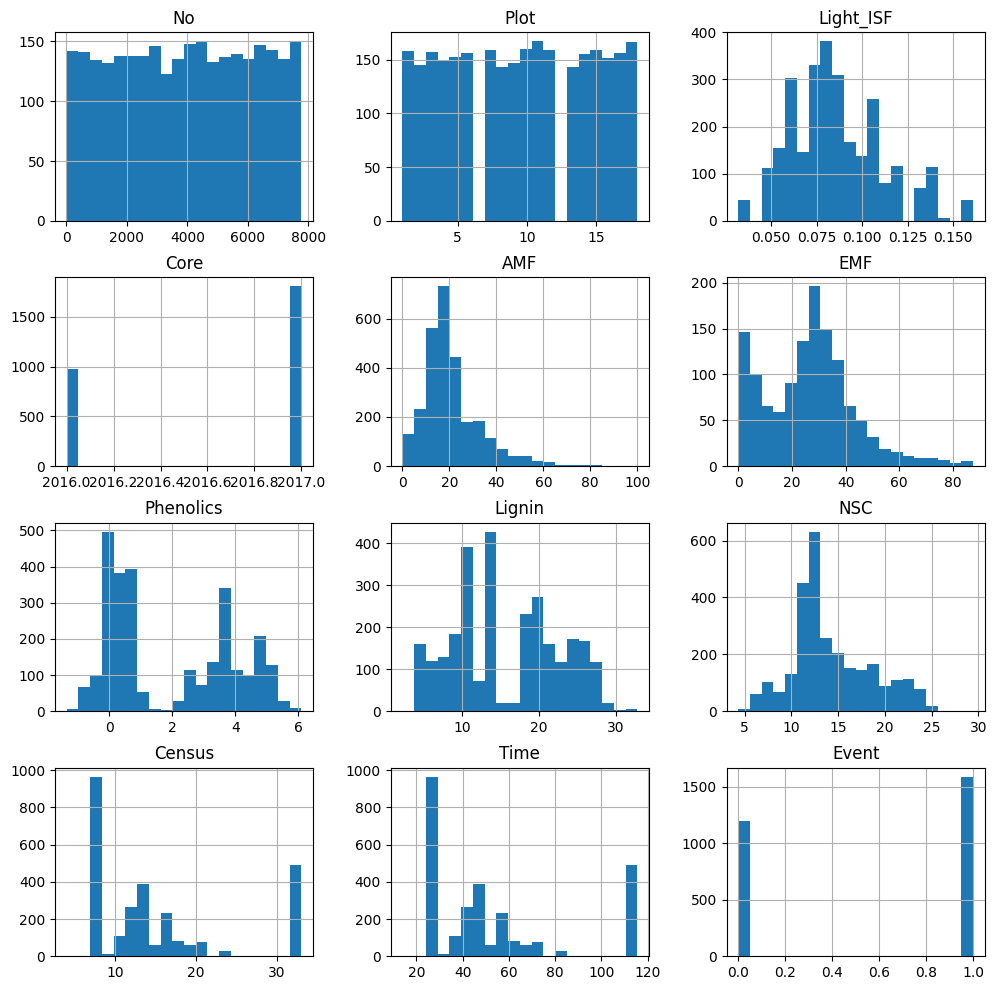

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

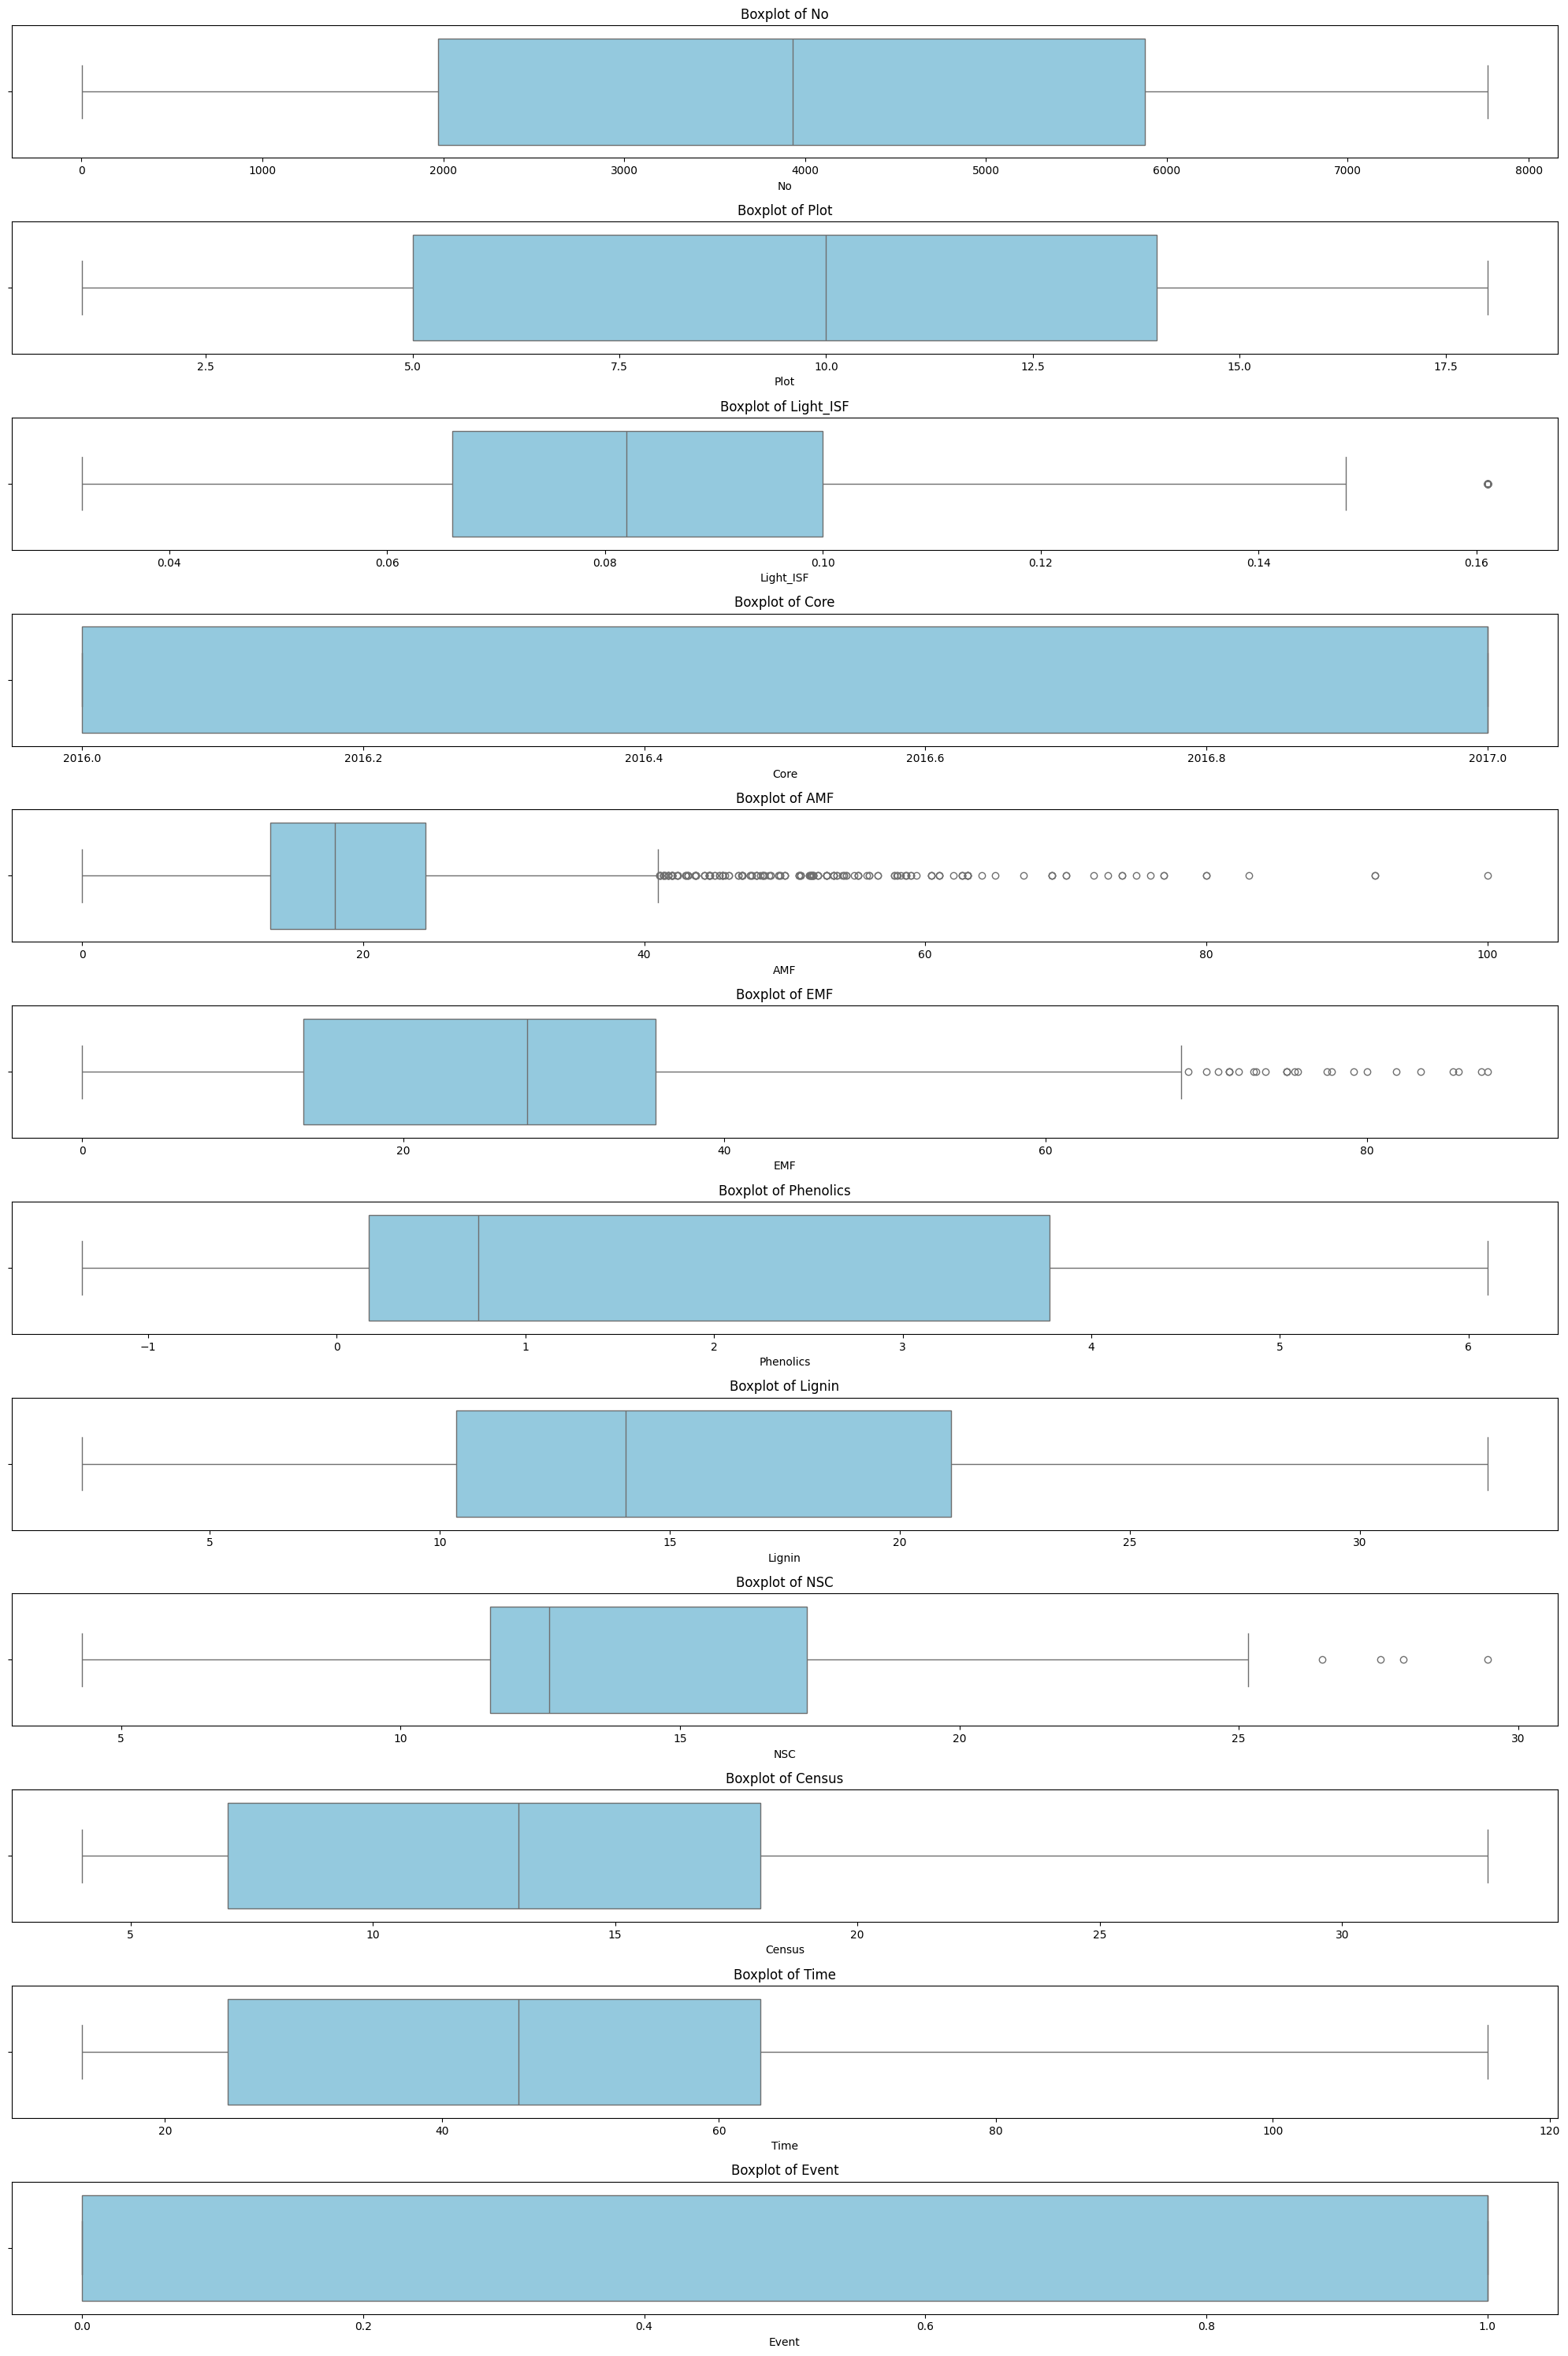

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = tree.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=tree[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


In [ ]:
numerical_data.nunique()

,0
No,2783
Plot,18
Light_ISF,53
Core,2
AMF,924
EMF,682
Phenolics,494
Lignin,1095
NSC,998
Census,22


In [ ]:
numerical_data.isnull().sum()

,0
No,0
Plot,0
Light_ISF,0
Core,0
AMF,0
EMF,1500
Phenolics,0
Lignin,0
NSC,0
Census,0


In [ ]:

unique_counts=categorical_data.nunique()
print(unique_counts)

Subplot         5
Species         4
Light_Cat       3
Soil            7
Adult          36
Sterile         2
Conspecific     3
Myco            2
SoilMyco        3
PlantDate      19
Harvest         1
Alive           1
dtype: int64


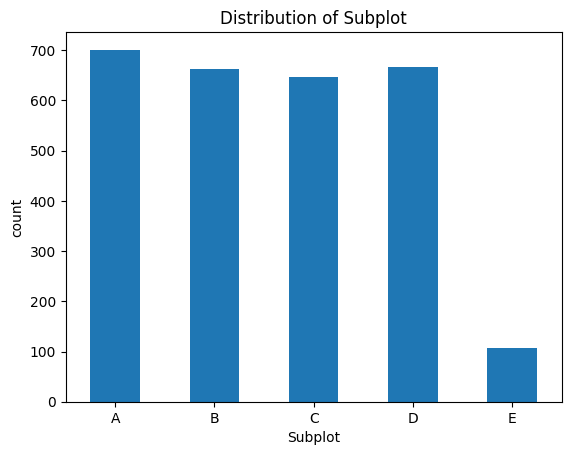

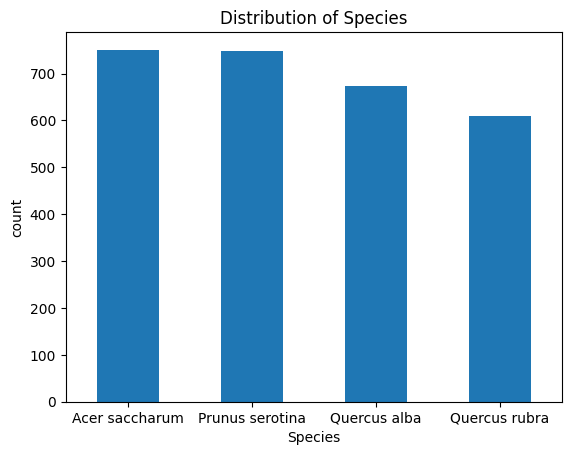

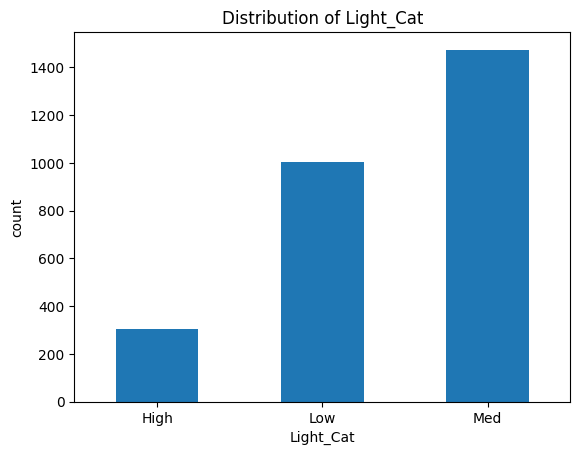

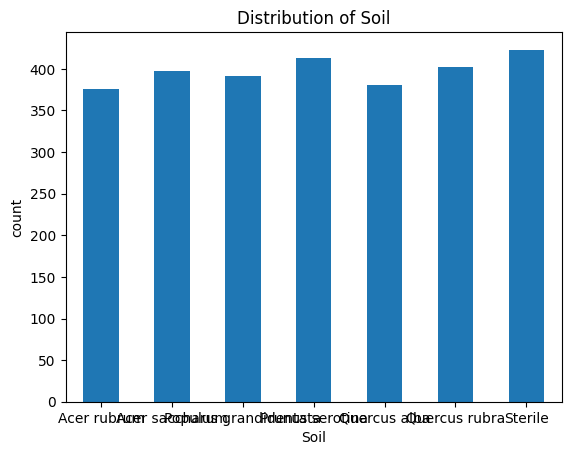

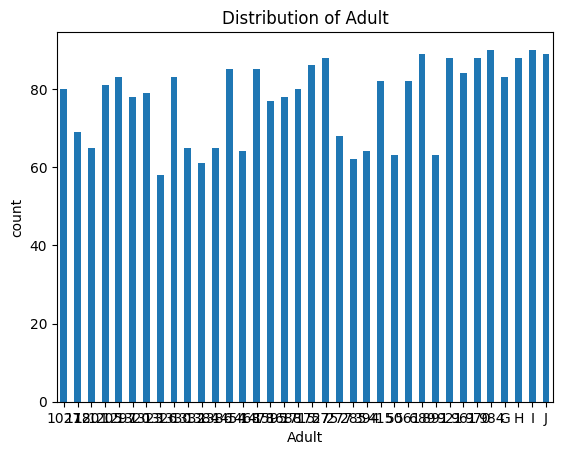

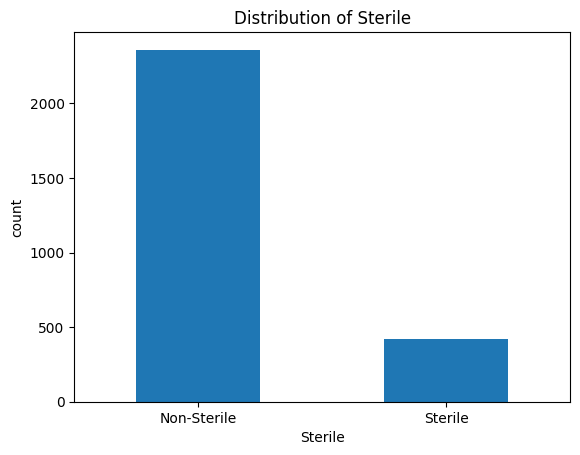

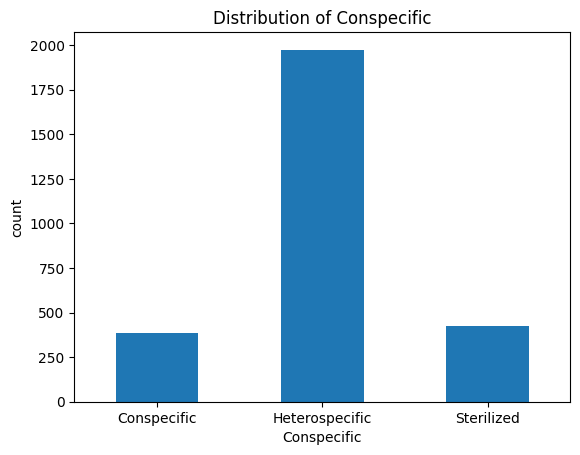

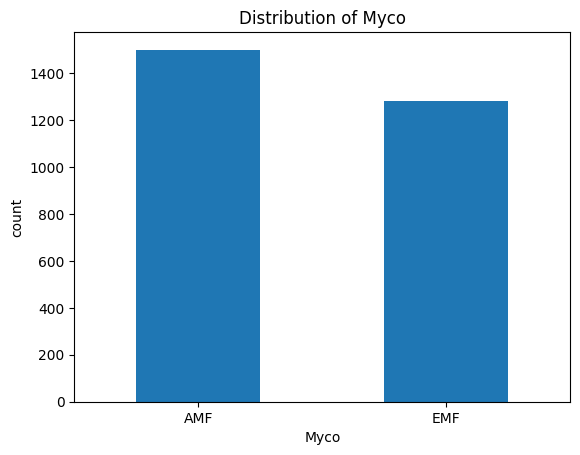

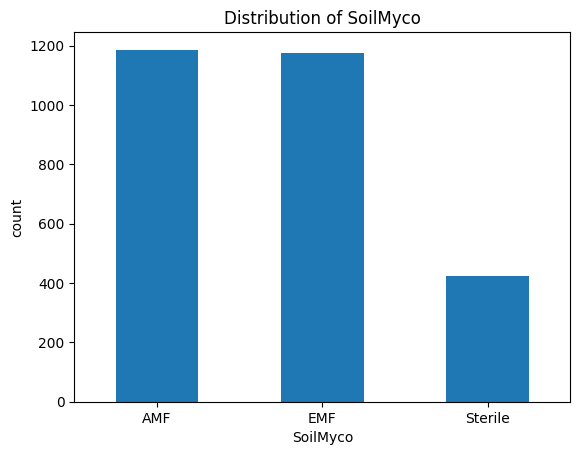

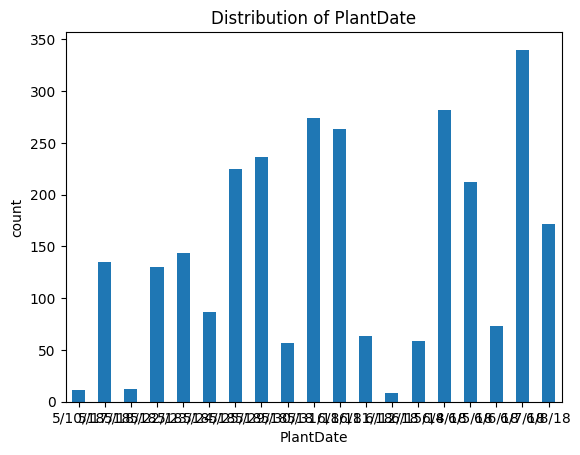

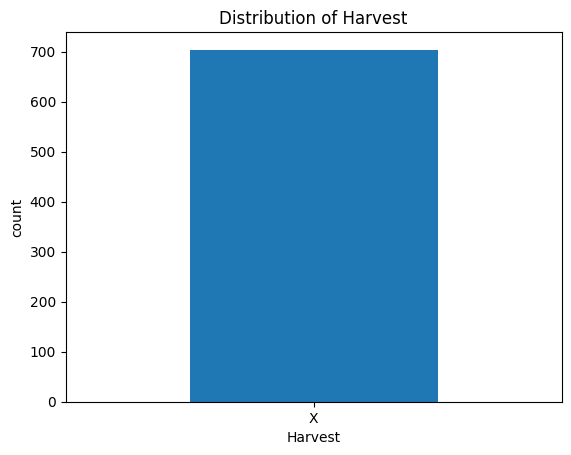

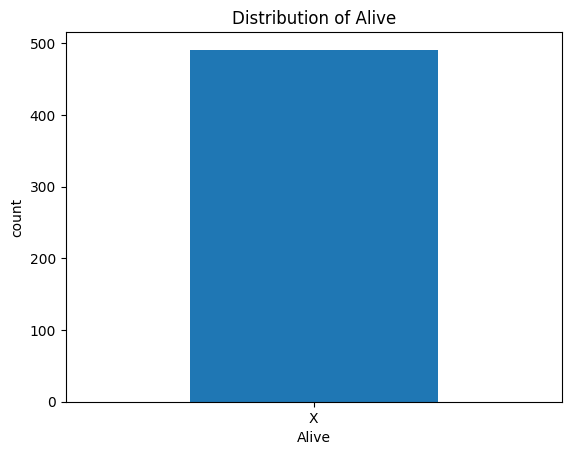

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix


,No,Plot,Light_ISF,Core,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event
No,1.000000,0.998450,0.250086,0.040238,0.082042,0.164707,0.038217,-0.008797,0.026681,-0.062410,-0.062410,-0.070230
Plot,0.998450,1.000000,0.248232,0.037724,0.083960,0.164957,0.038924,-0.009677,0.027051,-0.061303,-0.061303,-0.070711
Light_ISF,0.250086,0.248232,1.000000,0.049650,0.099120,0.163202,0.098531,0.081305,0.227706,0.026203,0.026203,-0.048473
Core,0.040238,0.037724,0.049650,1.000000,-0.056579,-0.140301,0.051929,0.088418,0.054315,0.048183,0.048183,-0.052738
AMF,0.082042,0.083960,0.099120,-0.056579,1.000000,0.264975,-0.121295,-0.304034,-0.181600,-0.090019,-0.090019,0.134544
EMF,0.164707,0.164957,0.163202,-0.140301,0.264975,1.000000,0.359696,0.055293,0.117529,0.001533,0.001533,-0.037480
Phenolics,0.038217,0.038924,0.098531,0.051929,-0.121295,0.359696,1.000000,0.768149,0.791244,0.379782,0.379782,-0.575633
Lignin,-0.008797,-0.009677,0.081305,0.088418,-0.304034,0.055293,0.768149,1.000000,0.546625,0.293374,0.293374,-0.519645
NSC,0.026681,0.027051,0.227706,0.054315,-0.181600,0.117529,0.791244,0.546625,1.000000,0.368411,0.368411,-0.410076
Census,-0.062410,-0.061303,0.026203,0.048183,-0.090019,0.001533,0.379782,0.293374,0.368411,1.000000,1.000000,-0.232227


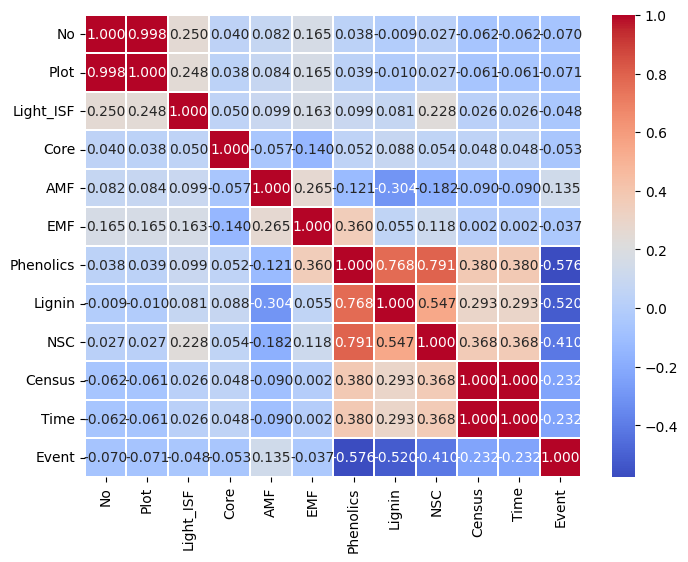

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

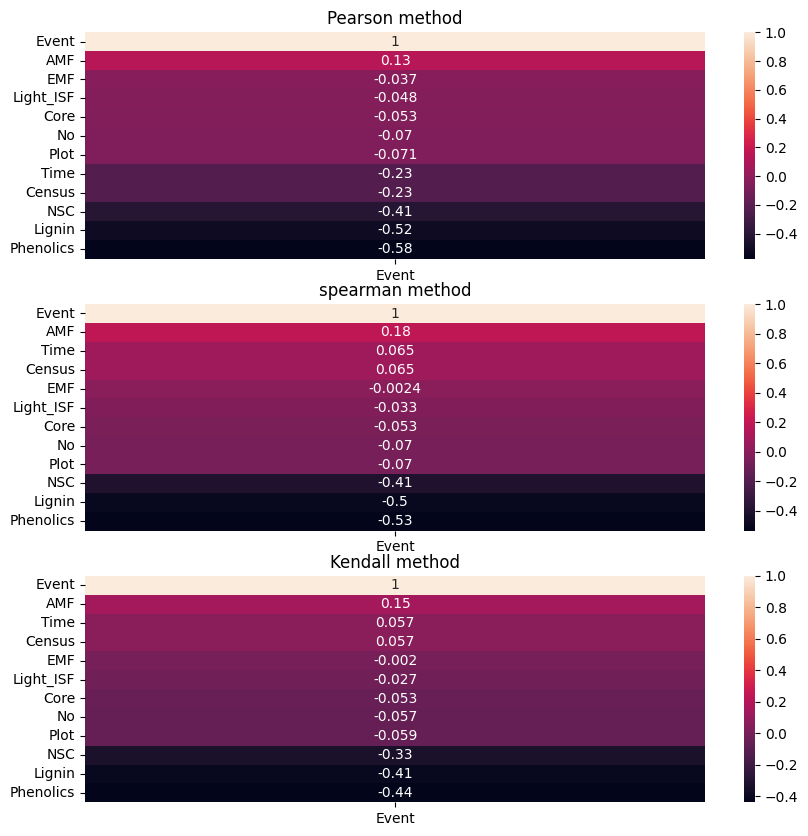

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['Event']].sort_values(by='Event', ascending=False)
corr2 = numerical_data.corr('spearman')[['Event']].sort_values(by='Event', ascending=False)
corr3 = numerical_data.corr('kendall')[['Event']].sort_values(by='Event', ascending=False)


ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')


sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

In [ ]:
class_counts=tree.groupby("Event").size()

columns=['event','count','percentage']
outcome=[0,1]
count=list()
percentage=list()


for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/105000)*100
    percentage.append(percent)


imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

,event,count,percentage
0,0,1195,1.138095
1,1,1587,1.511429


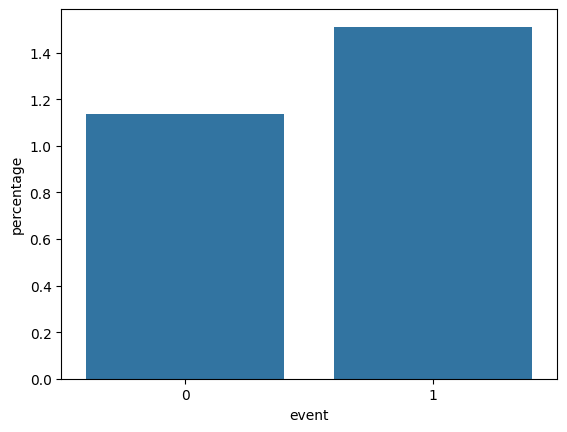

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['event'],y=imbalance_df['percentage'])
plt.show()


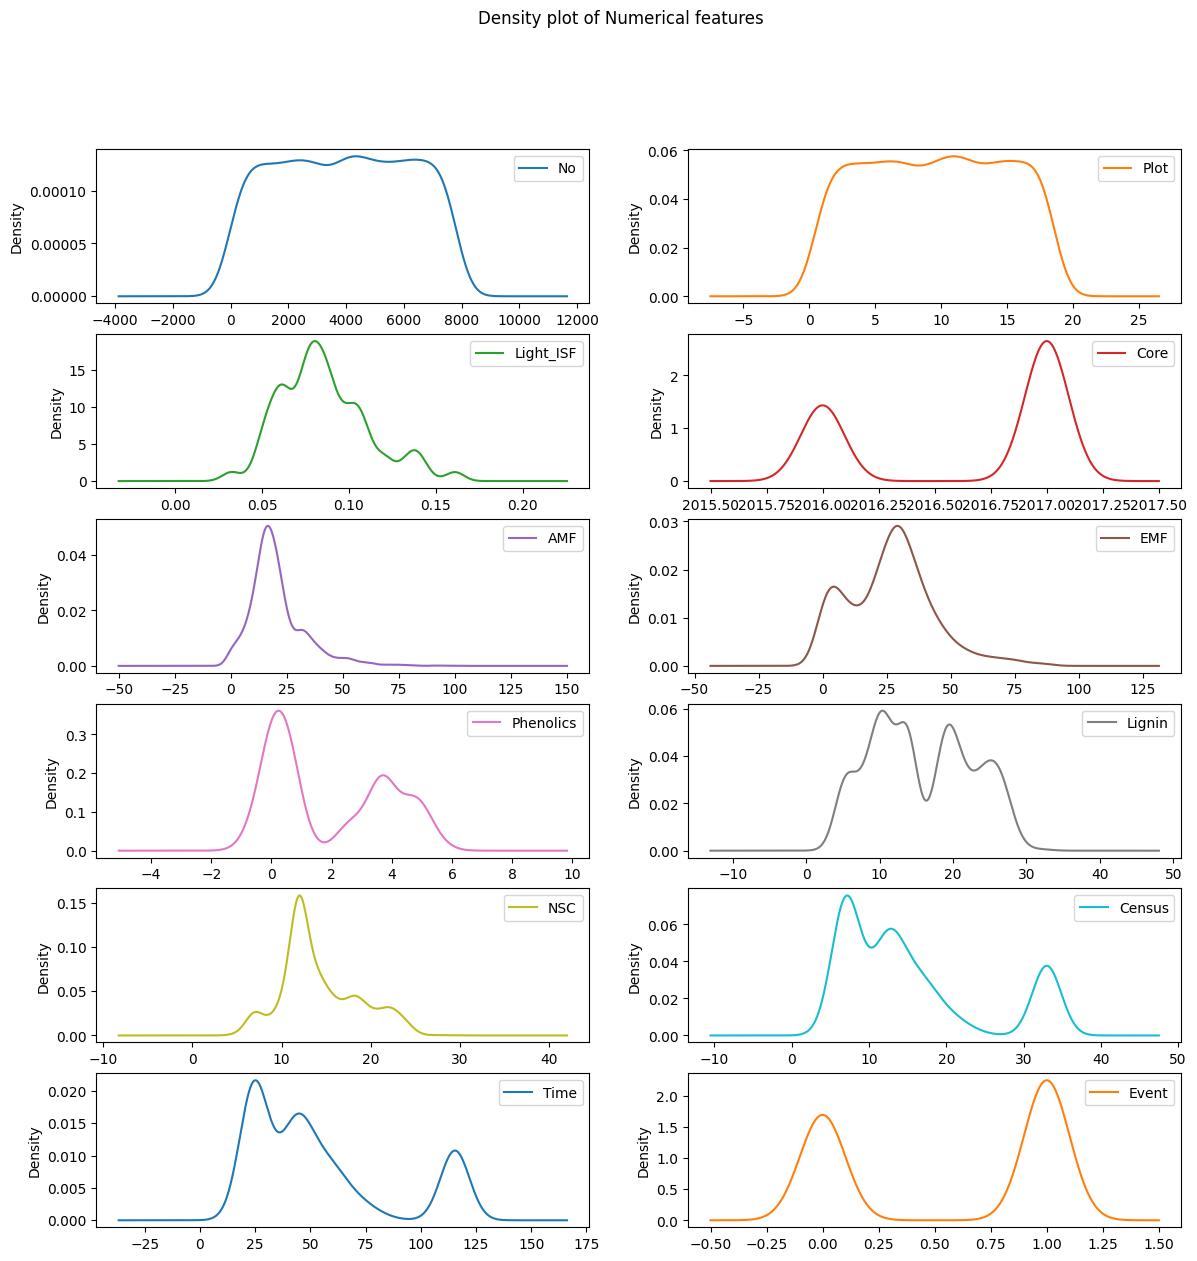

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
num_cols = tree.select_dtypes(include=['int64', 'float64']).columns
tree[num_cols] = tree[num_cols].fillna(tree[num_cols].mean())

cat_cols = tree.select_dtypes(include=['object']).columns
for col in cat_cols:
    tree[col] = tree[col].fillna(tree[col].mode()[0])


In [ ]:
cols_to_drop = [
    'No', 'Plot', 'Subplot', 'PlantDate', 'Census',
    'Time', 'Event', 'Harvest', 'Alive'
]

tree = tree.drop(columns=cols_to_drop)


In [ ]:
X = tree.drop('Sterile', axis=1)
y = tree['Sterile']

X = pd.get_dummies(X, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
log_reg = LogisticRegression(
    max_iter=300,
    C=0.5,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train, y_train_enc)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train_enc)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]


In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train_enc)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]


In [ ]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    alpha=0.05,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

nn.fit(X_train_scaled, y_train_enc)

y_pred_nn = nn.predict(X_test_scaled)
y_prob_nn = nn.predict_proba(X_test_scaled)[:, 1]


In [ ]:

models = ['KNN', 'Logistic Regression', 'Decision Tree', 'Neural Network']

precision = [
    precision_score(y_test_enc, y_pred_knn, average='macro', zero_division=0),
    precision_score(y_test_enc, y_pred_lr, average='macro', zero_division=0),
    precision_score(y_test_enc, y_pred_dt, average='macro', zero_division=0),
    precision_score(y_test_enc, y_pred_nn, average='macro', zero_division=0)
]

recall = [
    recall_score(y_test_enc, y_pred_knn, average='macro', zero_division=0),
    recall_score(y_test_enc, y_pred_lr, average='macro', zero_division=0),
    recall_score(y_test_enc, y_pred_dt, average='macro', zero_division=0),
    recall_score(y_test_enc, y_pred_nn, average='macro', zero_division=0)
]

accuracy = [
    accuracy_score(y_test_enc, y_pred_knn),
    accuracy_score(y_test_enc, y_pred_lr),
    accuracy_score(y_test_enc, y_pred_dt),
    accuracy_score(y_test_enc, y_pred_nn)
]

metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall
})

metrics_df


,Model,Accuracy,Precision,Recall
0,KNN,0.965889,0.925839,0.946112
1,Logistic Regression,1.000000,1.000000,1.000000
2,Decision Tree,1.000000,1.000000,1.000000
3,Neural Network,0.998205,0.994186,0.998941


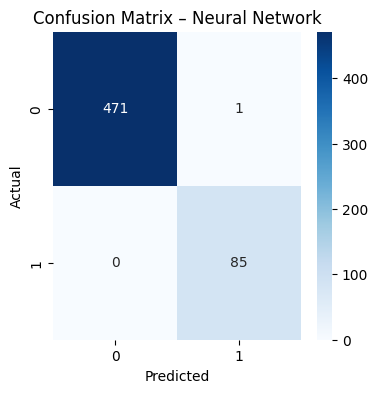

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred_nn)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Neural Network")
plt.show()


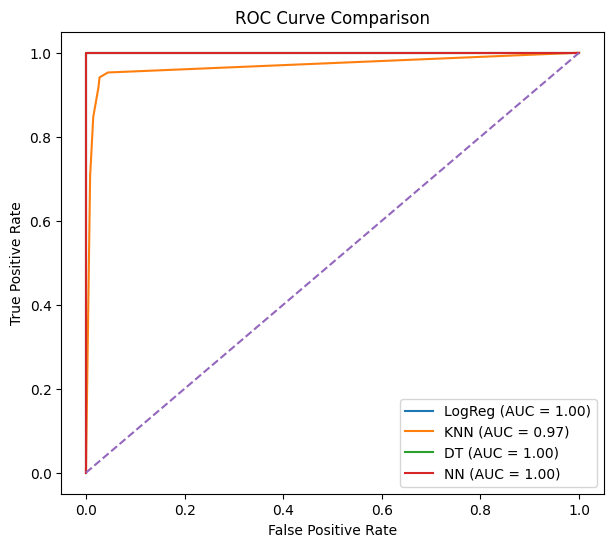

In [ ]:
plt.figure(figsize=(7,6))


fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC = {auc_lr:.2f})")


fpr_knn, tpr_knn, _ = roc_curve(y_test_enc, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")


fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC = {auc_dt:.2f})")


fpr_nn, tpr_nn, _ = roc_curve(y_test_enc, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f"NN (AUC = {auc_nn:.2f})")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


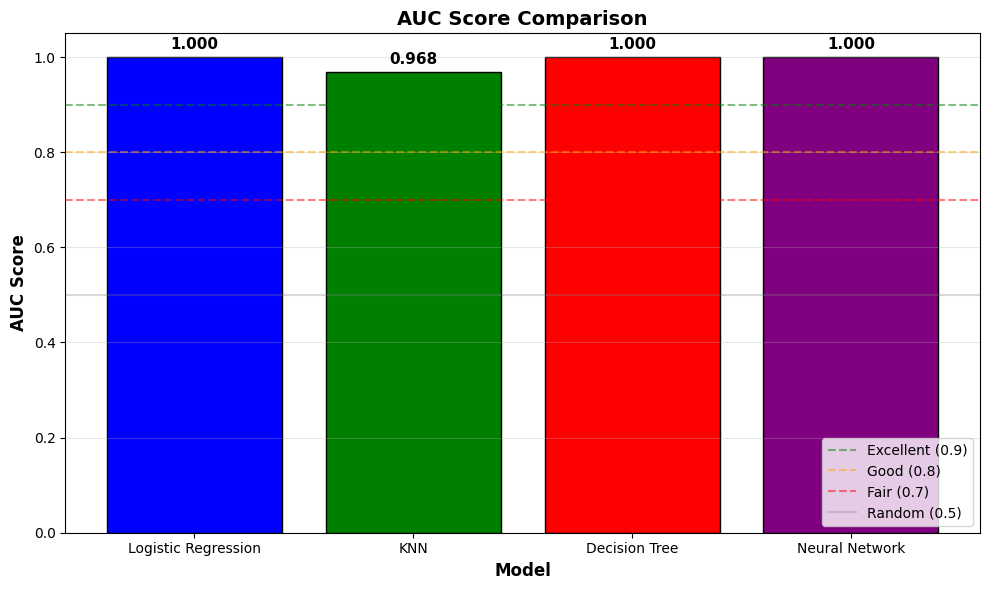

AUC Scores:
Logistic Regression: 1.0000
KNN: 0.9683
Decision Tree: 1.0000
Neural Network: 1.0000

Best Model: Decision Tree with AUC = 1.0000


In [ ]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_test_enc, y_prob_lr)
auc_knn = roc_auc_score(y_test_enc, y_prob_knn)
auc_dt = roc_auc_score(y_test_enc, y_prob_dt)
auc_nn = roc_auc_score(y_test_enc, y_prob_nn)

import matplotlib.pyplot as plt

models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Neural Network']
auc_values = [auc_lr, auc_knn, auc_dt, auc_nn]
colors = ['blue', 'green', 'red', 'purple']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, auc_values, color=colors, edgecolor='black')

for bar, value in zip(bars, auc_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Excellent (0.9)')
plt.axhline(y=0.8, color='orange', linestyle='--', alpha=0.5, label='Good (0.8)')
plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Fair (0.7)')
plt.axhline(y=0.5, color='gray', linestyle='-', alpha=0.3, label='Random (0.5)')

plt.ylim([0, 1.05])
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('AUC Score', fontsize=12, fontweight='bold')
plt.title('AUC Score Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC Scores:")
for model, score in zip(models, auc_values):
    print(f"{model}: {score:.4f}")

best_idx = auc_values.index(max(auc_values))
print(f"\nBest Model: {models[best_idx]} with AUC = {auc_values[best_idx]:.4f}")